In [ ]:
import pandas as pd
diagnosed_users = pd.read_csv('data/metadata/majority-vote-reddit.csv')
posts = pd.read_csv('data/posts/v1/reddit-preprocessed.csv')
diagnosed_users = diagnosed_users.drop(columns=['platform'])
posts = posts.drop(columns=['Unnamed: 0'])
display(diagnosed_users.head(2))
display(posts.head(2))

In [29]:
display(diagnosed_users.describe(include='all'))
display(posts.describe(include='all'))

,id,text,author,created_utc,subreddit,is_comment,diagnosis
count,6753,6631,6753,6753,6753,6753,6753
unique,6753,6409,4959,6752,50,2,13
top,10015uu,اولا جمعة مباركة عليكم، اللهم صل وسلم على محمد...,Business_Thing875,2025-09-14 20:38:00+00:00,AlexandriaEgy,True,depression
freq,1,8,61,2,1333,3733,2728


,user_id,class,text
count,1115379,928981,1115379
unique,9149,19,1068978
top,Silll9s,control,اتمني النهارده كان حلو بالنسبه لك و زي كل يوم ...
freq,2303,264469,72


In [30]:
display(diagnosed_users['diagnosis'].value_counts())
# count unique uesers per class in the posts dataset
for c in posts['class'].unique():
    print(f'Num users in class {c}: {posts[posts['class'] == c]['user_id'].nunique()}')

diagnosis
depression         2728
anxiety             955
adhd                830
ocd                 550
sleep_disorder      448
autism              296
panic               203
bipolar             177
ptsd                161
bpd                 136
suicidal            110
schizophrenia        96
eating_disorder      63
Name: count, dtype: int64

Num users in class adhd: 643
Num users in class bpd: 98
Num users in class depression: 1831
Num users in class control: 4080
Num users in class panic: 147
Num users in class sleep_disorder: 357
Num users in class ocd: 311
Num users in class schizophrenia: 45
Num users in class autism: 227
Num users in class anxiety: 644
Num users in class nan: 0
Num users in class ptsd: 92
Num users in class suicidal: 80
Num users in class eating_disorder: 41
Num users in class bipolar: 76
Num users in class narcissistic_pd: 3
Num users in class paranoid_pd: 24
Num users in class trichotillomania: 9
Num users in class did: 11
Num users in class avoidant_pd: 3


In [ ]:
print(f'Diagnosed users: {diagnosed_users['author'].nunique()}')
print(f'Posts users: {posts[posts['class'] != 'control']['user_id'].nunique()}')
# missing users in posts dataset
+
missing_users = set(diagnosed_users['author'].unique()) - set(posts[posts['class'] != 'control']['user_id'].unique())
print(f'Missing users: {len(missing_users)}')
poss_users = set(posts['user_id'].unique())
missing_users

Diagnosed users: 4959
Posts users: 5402
Missing users: 106


{'0mo06_',
 '3m_Armoty',
 '7je_0',
 'Amazing-Answer-5639',
 'AndrewHany08',
 'Appropriate_Fox_7322',
 'Bedo20056',
 'Big-Championship7536',
 'BravePerformance6167',
 'Brave_Bumblebee_4056',
 'Budget_Deer_67',
 'CherryEllla',
 'Clear_Historian8551',
 'Commercial-Phase8377',
 'Consistent_Turn7964',
 'Dependent_Pie4078',
 'EmbarrassedSoil8218',
 'Evening_Meet7216',
 'Extension_Review596',
 'Familiar-Health-8418',
 'Federal-Election6060',
 'Formal_Discipline585',
 'Fun-Vehicle3581',
 'FunDrag7212',
 'Guilty_Race2932',
 'Hkmao',
 'Hopeful_Reserve6277',
 'Hour-Management-1679',
 'IStoppedNamingThings',
 'ImaginaryFlatworm796',
 'Intelligent_Owl_3841',
 'Just-Artichoke4267',
 'LILKAYYYY99',
 'Lopsided_Trick_8500',
 'Mammoth-Appeal5016',
 'MohamedAkm0',
 'Mohammed00900',
 'Necessary_Air7147',
 'Novel-Caterpillar-46',
 'Ok-Marionberry-2939',
 'Ok_Picture_5229',
 'Ok_Sorbet9253',
 'Omsd3364',
 'Osos513',
 'Own-Door5373',
 'Positive_Fold_8780',
 'Prior_Soft_543',
 'Puzzleheaded-Fun9828',
 'Qmrss2

In [40]:
# save as txt
# with open('missing-reddit-users.txt', 'w') as f:
#     for user in missing_users:
#         f.write(f"{user}\n")
print(len(poss_users))

9149


In [38]:
print(posts['text'][:5])

0    الله عليك يا عبغفور ماشي بمبدا معنديش حاجة اخس...
1    غلط عن غلط يفرق الضرب والتعنيف من المحرمات في ...
2    اقل مسلم بيكفرك من غير ما يعرف اسمك حتي ، شوية...
3    كلمت ابويا عن المثليين قولتله هو انا عندي سؤال...
4    اجهزه تعدين من فين اقدر اشتريها ؟ لو حد يقدر ي...
Name: text, dtype: str


# Dataset Statistics for Manuscript

Sections 1-3 (scale/coverage, text statistics, Arabic dialect identification) are the main-paper statistics.
Section 4 (appendix) covers data-quality diagnostics: code-switching, duplicates, class overlap, unlabeled rows.

## 1. Scale & Class Coverage

In [41]:
import numpy as np

posts_labeled = posts.dropna(subset=['class']).copy()
n_unlabeled = len(posts) - len(posts_labeled)

class_counts = posts_labeled['class'].value_counts()
users_per_class = posts_labeled.groupby('class')['user_id'].nunique()
posts_per_user = posts_labeled.groupby(['class', 'user_id']).size()

class_stats = pd.DataFrame({
    'n_posts': class_counts,
    'pct_of_posts': (class_counts / len(posts_labeled) * 100).round(2),
    'n_users': users_per_class,
})
class_stats['posts_per_user_mean'] = posts_per_user.groupby('class').mean().round(1)
class_stats['posts_per_user_median'] = posts_per_user.groupby('class').median()
class_stats['posts_per_user_max'] = posts_per_user.groupby('class').max()
class_stats = class_stats.sort_values('n_posts', ascending=False)

print(f"Total posts: {len(posts):,} ({n_unlabeled:,} unlabeled / {n_unlabeled/len(posts)*100:.1f}% dropped below)")
print(f"Total labeled posts: {len(posts_labeled):,}")
print(f"Total unique users: {posts_labeled['user_id'].nunique():,}")
print(f"Total classes: {posts_labeled['class'].nunique()}")
display(class_stats)

Total posts: 1,115,379 (186,398 unlabeled / 16.7% dropped below)
Total labeled posts: 928,981
Total unique users: 8,487
Total classes: 19


,n_posts,pct_of_posts,n_users,posts_per_user_mean,posts_per_user_median,posts_per_user_max
class,,,,,,
control,264469,28.47,4080,64.8,19.0,995
depression,251809,27.11,1831,137.5,59.0,1267
adhd,101107,10.88,643,157.2,73.0,862
anxiety,90082,9.70,644,139.9,59.5,1013
sleep_disorder,60666,6.53,357,169.9,115.0,938
ocd,39413,4.24,311,126.7,50.0,924
autism,32292,3.48,227,142.3,71.0,769
panic,20849,2.24,147,141.8,59.0,891
ptsd,15627,1.68,92,169.9,106.0,1108


**Note on concentration:** `posts_per_user_max` reaches into the hundreds/low-thousands for
several classes (e.g. a single `depression` user contributes up to ~1,200+ posts). This means
class-level post counts are not equivalent to "number of independent observations" — worth
reporting `n_users` alongside `n_posts` in the manuscript, and worth a user-level (not
post-level) train/test split to avoid leakage.

## 2. Text Statistics

In [42]:
import re

# Tokens = contiguous Arabic-letter runs. Punctuation/digits/Latin script are excluded here;
# Latin-script content is measured separately as code-switching in the appendix.
ARABIC_TOKEN_RE = re.compile(r'[؀-ۿ]+')

def tokenize_ar(text):
    return ARABIC_TOKEN_RE.findall(text) if isinstance(text, str) else []

posts_labeled['tokens'] = posts_labeled['text'].map(tokenize_ar)
posts_labeled['word_count'] = posts_labeled['tokens'].map(len)
posts_labeled['char_count'] = posts_labeled['text'].str.len()

def doc_ttr(tokens):
    return len(set(tokens)) / len(tokens) if tokens else np.nan

posts_labeled['doc_ttr'] = posts_labeled['tokens'].map(doc_ttr)

length_stats = posts_labeled.groupby('class').agg(
    word_count_mean=('word_count', 'mean'),
    word_count_median=('word_count', 'median'),
    word_count_std=('word_count', 'std'),
    char_count_mean=('char_count', 'mean'),
    char_count_median=('char_count', 'median'),
).round(1).sort_values('word_count_mean', ascending=False)

display(length_stats)

,word_count_mean,word_count_median,word_count_std,char_count_mean,char_count_median
class,,,,,
schizophrenia,61.5,25.0,116.4,302.2,125.0
narcissistic_pd,48.9,30.0,55.1,257.8,157.0
did,46.9,23.0,78.4,244.0,119.0
suicidal,46.1,26.0,61.3,230.9,132.0
control,45.6,27.0,64.2,230.0,134.0
ocd,45.3,25.0,81.1,227.9,125.0
paranoid_pd,45.1,27.0,54.6,227.9,136.0
trichotillomania,45.0,27.0,48.3,215.9,128.0
ptsd,42.9,26.0,52.3,216.2,129.0


In [43]:
# Lexical diversity: mean per-document type-token ratio (TTR), not corpus-level TTR
# (corpus-level TTR is biased downward by class size / number of posts, which just
# tracks n_posts from Section 1 rather than telling us anything new).
diversity_stats = posts_labeled[posts_labeled['word_count'] >= 5].groupby('class').agg(
    mean_doc_ttr=('doc_ttr', 'mean'),
    vocab_size=('tokens', lambda s: len(set(w for toks in s for w in toks))),
).sort_values('mean_doc_ttr')

display(diversity_stats)

,mean_doc_ttr,vocab_size
class,,
trichotillomania,0.881788,5313
schizophrenia,0.885007,69508
suicidal,0.895070,68429
control,0.900131,419164
ptsd,0.902231,83351
narcissistic_pd,0.902412,13013
ocd,0.903190,148010
paranoid_pd,0.905109,37400
did,0.905810,23796


## 3. Arabic Dialect Identification & Coverage

Most Arabic mental-health NLP datasets are MSA- or Egyptian-only; this dataset draws from
many regional subreddits, so dialectal coverage is worth reporting as a distinguishing
feature. We use CAMeL Tools' `DIDModel6` (MADAR-trained Naive-Bayes dialect identifier),
the standard tool for this task in Arabic NLP, which classifies text into 5 city dialects +
MSA. City labels are grouped into 5 regions for reporting: `CAI`→Egypt, `DOH`→Gulf,
`BEI`→Levant, `TUN`/`RAB`→Maghreb, `MSA`→MSA.

Running the model over all ~929K labeled posts would take hours single-threaded, so we run it
on a **stratified random sample capped at 1,500 posts/class** (all posts for classes with
fewer), with a 16-worker multiprocessing pool. n=1,500 gives a ~2.5% margin of error at 95%
CI for the proportion estimates below — adequate for a coverage statistic. Posts under 5
Arabic words are excluded (too short for reliable dialect ID). Results are cached to
`data/metadata/dialect_id_sample.csv` so this only needs to run once.

In [44]:
import warnings
from multiprocessing import Pool, cpu_count
from pathlib import Path

warnings.filterwarnings('ignore', category=UserWarning)  # sklearn pickle-version warnings from the pretrained DID model

DIALECT_CACHE_PATH = Path('data/metadata/dialect_id_sample.csv')
SAMPLE_PER_CLASS = 1500
MIN_WORDS_FOR_DID = 5
DID_REGION_MAP = {'CAI': 'Egypt', 'DOH': 'Gulf', 'BEI': 'Levant', 'TUN': 'Maghreb', 'RAB': 'Maghreb', 'MSA': 'MSA'}

_did = None

def _init_did_worker():
    global _did
    from camel_tools.dialectid import DIDModel6
    _did = DIDModel6.pretrained()

def _predict_chunk(chunk):
    return [p.top for p in _did.predict(chunk)]

if DIALECT_CACHE_PATH.exists():
    dialect_sample = pd.read_csv(DIALECT_CACHE_PATH)
else:
    eligible = posts_labeled[posts_labeled['word_count'] >= MIN_WORDS_FOR_DID]
    parts = []
    for cls, g in eligible.groupby('class'):
        n = min(len(g), SAMPLE_PER_CLASS)
        parts.append(g.sample(n=n, random_state=42))
    dialect_sample = pd.concat(parts, ignore_index=True)[['user_id', 'class', 'text', 'word_count']]

    texts = dialect_sample['text'].tolist()
    chunks = [texts[i:i + 100] for i in range(0, len(texts), 100)]
    with Pool(min(16, cpu_count()), initializer=_init_did_worker) as pool:
        chunked_preds = pool.map(_predict_chunk, chunks)
    dialect_sample['dialect_code'] = [d for chunk in chunked_preds for d in chunk]
    dialect_sample['dialect_region'] = dialect_sample['dialect_code'].map(DID_REGION_MAP)

    DIALECT_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    dialect_sample.to_csv(DIALECT_CACHE_PATH, index=False)

print(f"Dialect sample: {len(dialect_sample):,} posts across {dialect_sample['class'].nunique()} classes")
display(dialect_sample.head(3))

Dialect sample: 25,758 posts across 19 classes


,user_id,class,text,word_count,dialect_code,dialect_region
0,Wildmiffy,adhd,علي حسب الجنسيه الي بتاخذينها بس اذا ابوهم يست...,11,DOH,Gulf
1,Abdoolz,adhd,نعم فيه ، كل البنوك عندها صناديق هذا رابط الصن...,13,MSA,MSA
2,tiko_ben_laden,adhd,حرفيا انا بصحي اكل وافتح اتح المحاضره واقعد نص...,15,DOH,Gulf


In [45]:
REGION_ORDER = ['MSA', 'Egypt', 'Gulf', 'Levant', 'Maghreb']

overall_dialect_dist = dialect_sample['dialect_region'].value_counts(normalize=True).mul(100).round(1)
overall_dialect_dist = overall_dialect_dist.reindex(REGION_ORDER)

per_class_dialect_dist = pd.crosstab(dialect_sample['class'], dialect_sample['dialect_region'], normalize='index').mul(100).round(1)
per_class_dialect_dist = per_class_dialect_dist.reindex(columns=REGION_ORDER).fillna(0)
per_class_dialect_dist = per_class_dialect_dist.loc[class_stats.index]  # same class order as Section 1

print("Overall dialect distribution (% of sampled posts):")
display(overall_dialect_dist)
print("\nPer-class dialect distribution (% of sampled posts):")
display(per_class_dialect_dist)

Overall dialect distribution (% of sampled posts):


dialect_region
MSA         6.6
Egypt      56.1
Gulf       30.9
Levant      3.7
Maghreb     2.7
Name: proportion, dtype: float64


Per-class dialect distribution (% of sampled posts):


dialect_region,MSA,Egypt,Gulf,Levant,Maghreb
class,,,,,
control,5.2,66.7,21.1,4.3,2.6
depression,5.4,57.3,31.6,3.3,2.5
adhd,6.1,51.7,35.7,3.3,3.1
anxiety,3.6,62.5,26.9,4.3,2.7
sleep_disorder,4.9,56.3,32.3,3.9,2.5
ocd,5.7,61.7,28.3,1.8,2.5
autism,5.9,59.7,29.1,2.9,2.5
panic,7.4,34.5,50.5,3.9,3.7
ptsd,4.8,57.1,32.8,2.7,2.7


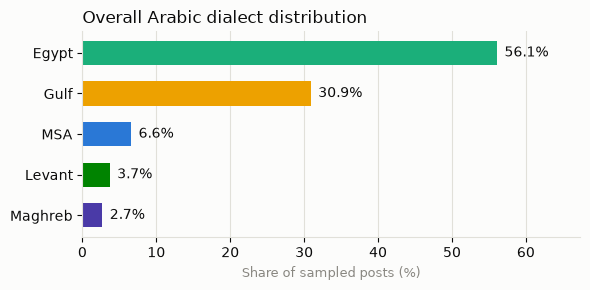

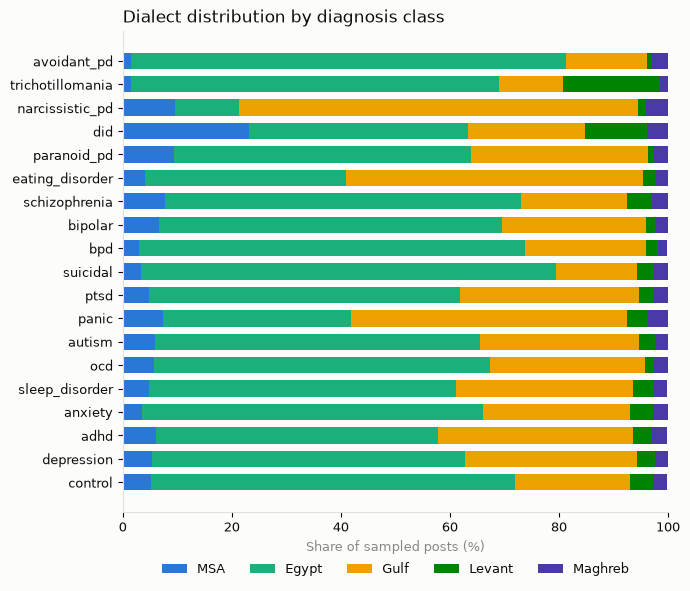

In [46]:
import matplotlib.pyplot as plt

REGION_COLORS = {
    'MSA': '#2a78d6', 'Egypt': '#1baf7a', 'Gulf': '#eda100',
    'Levant': '#008300', 'Maghreb': '#4a3aa7',
}
SURFACE, INK_PRIMARY, INK_MUTED, GRIDLINE = '#fcfcfb', '#0b0b0b', '#898781', '#e1e0d9'

# --- Figure 1: overall dialect distribution ---
overall_sorted = overall_dialect_dist.sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(6, 3), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
bars = ax.barh(overall_sorted.index, overall_sorted.values,
                color=[REGION_COLORS[r] for r in overall_sorted.index], height=0.6)
for bar, val in zip(bars, overall_sorted.values):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2, f'{val:.1f}%',
            va='center', ha='left', color=INK_PRIMARY, fontsize=10)
ax.set_xlim(0, max(overall_sorted.values) * 1.2)
ax.set_xlabel('Share of sampled posts (%)', color=INK_MUTED, fontsize=9)
ax.set_title('Overall Arabic dialect distribution', color=INK_PRIMARY, fontsize=12, loc='left')
ax.tick_params(colors=INK_PRIMARY, labelsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color(GRIDLINE)
ax.xaxis.grid(True, color=GRIDLINE, linewidth=0.8)
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig('data/posts/v1/fig_dialect_overall.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Figure 2: dialect distribution by diagnosis class ---
fig, ax = plt.subplots(figsize=(7, 6), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
left = pd.Series(0.0, index=per_class_dialect_dist.index)
for region in REGION_ORDER:
    vals = per_class_dialect_dist[region]
    ax.barh(per_class_dialect_dist.index, vals, left=left, color=REGION_COLORS[region], height=0.7, label=region)
    left = left + vals
ax.set_xlim(0, 100)
ax.set_xlabel('Share of sampled posts (%)', color=INK_MUTED, fontsize=9)
ax.set_title('Dialect distribution by diagnosis class', color=INK_PRIMARY, fontsize=12, loc='left')
ax.tick_params(colors=INK_PRIMARY, labelsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color(GRIDLINE)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=5, frameon=False, fontsize=9, labelcolor=INK_PRIMARY)
fig.tight_layout()
fig.savefig('data/posts/v1/fig_dialect_by_class.png', dpi=300, bbox_inches='tight')
plt.show()